# Wearable Biometric Risk Monitoring Project

## 프로젝트 개요

이번 프로젝트는 웨어러블 센서 데이터를 이용해 생체지표의 위험 패턴을 분석하는 프로젝트이다.

데이터에는 심박수, 산소포화도, 체온, 호흡수, 걸음 수, 활동 종류, 센서 오류 여부 등이 포함되어 있다.

본 프로젝트에서는 같은 데이터를 MySQL과 MongoDB에 각각 저장한 뒤, SQLAlchemy와 PyMongo를 이용해 동일한 분석을 수행한다.

이를 통해 관계형 데이터베이스와 NoSQL 데이터베이스에서 데이터를 저장하고, 조회하고, 집계하는 과정을 비교한다.

## 분석 목표

- 활동별 평균 생체지표 분석
- 고심박, 고체온, 저산소 위험 이벤트 탐지
- 센서 오류 데이터 확인
- 시간대별 생체지표 패턴 분석
- 이상치 제거 전후 비교
- SQLAlchemy와 PyMongo 분석 결과 비교

## 프로젝트 목적

이 프로젝트의 목적은 단순히 데이터를 조회하는 것이 아니라, 웨어러블 센서 데이터에서 위험 신호를 탐지하고 데이터 품질을 점검하는 것이다.

또한 SQLAlchemy와 PyMongo를 모두 활용하여 SQL 기반 분석과 NoSQL 기반 분석을 각각 구현해보는 것을 목표로 한다.

# 1. 데이터 불러오기 및 기본 확인

이번 단계에서는 Google Drive에 저장된 웨어러블 센서 CSV 파일을 불러온다.

데이터를 바로 분석하기 전에 먼저 행과 컬럼 수, 컬럼 이름, 결측치, 활동 종류, 시간 범위를 확인한다.

특히 timestamp 컬럼은 나중에 시간대별 분석에 사용할 예정이므로 datetime 타입으로 변환한다.

In [1]:
# ============================================================
# 1-1. Google Drive 연결
# ============================================================
# Google Drive에 저장된 CSV 파일을 Colab에서 불러오기 위해 Drive를 연결한다.

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive 연결 완료")

Mounted at /content/drive
Google Drive 연결 완료


In [2]:
# ============================================================
# 1-2. CSV 파일 불러오기
# ============================================================
# Google Drive에 저장된 웨어러블 센서 데이터를 불러온다.
# timestamp는 나중에 시간대별 분석에 쓰기 위해 datetime 타입으로 바꾼다.

import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/파이썬 강의/강의파일 3주차/biometric_wearable_dataset.csv"

df = pd.read_csv(file_path)

df["timestamp"] = pd.to_datetime(df["timestamp"])

print("데이터 불러오기 완료")
print("데이터 크기:", df.shape)

데이터 불러오기 완료
데이터 크기: (5000, 14)


In [3]:
# ============================================================
# 1-3. 데이터 기본 확인
# ============================================================
# 데이터가 제대로 불러와졌는지 기본 정보를 확인한다.
# 결측치, 활동 종류, 시간 범위를 먼저 확인하고 다음 분석으로 넘어간다.

print("===== 데이터 앞부분 =====")
display(df.head())

print("\n===== 컬럼 정보 =====")
df.info()

print("\n===== 결측치 개수 =====")
display(df.isnull().sum())

print("\n===== 활동별 데이터 개수 =====")
display(df["activity"].value_counts())

print("\n===== 시간 범위 =====")
print("시작 시각:", df["timestamp"].min())
print("마지막 시각:", df["timestamp"].max())

print("\n===== 숫자형 기본 통계 =====")
display(df.describe())

===== 데이터 앞부분 =====


,timestamp,heart_rate,blood_oxygen,body_temp,resp_rate,step_count,activity,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,is_tampered
0,2024-04-01 00:00:00,163.0,90.901136,36.312052,13.0,100,Cycling,-1.010299,-0.313778,-1.237370,37.323647,156.479698,-245.792228,0
1,2024-04-01 00:00:10,60.0,97.704815,37.721168,19.0,7,Resting,1.485340,-0.222970,-0.013984,-1.063077,88.243246,165.910361,0
2,2024-04-01 00:00:20,115.0,96.168169,37.728760,13.0,171,Walking,-1.320600,-0.910052,-1.403447,-240.402469,235.152740,-237.314053,0
3,2024-04-01 00:00:30,177.0,95.986372,38.856712,22.0,95,Cycling,1.406346,-0.850460,-0.920604,-206.882084,193.516981,-188.820969,0
4,2024-04-01 00:00:40,63.0,92.925404,37.327712,19.0,161,Walking,1.091390,0.795830,-0.069070,-71.995709,238.830512,169.334560,0



===== 컬럼 정보 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     5000 non-null   datetime64[ns]
 1   heart_rate    5000 non-null   float64       
 2   blood_oxygen  5000 non-null   float64       
 3   body_temp     5000 non-null   float64       
 4   resp_rate     5000 non-null   float64       
 5   step_count    5000 non-null   int64         
 6   activity      5000 non-null   object        
 7   accel_x       5000 non-null   float64       
 8   accel_y       5000 non-null   float64       
 9   accel_z       5000 non-null   float64       
 10  gyro_x        5000 non-null   float64       
 11  gyro_y        5000 non-null   float64       
 12  gyro_z        5000 non-null   float64       
 13  is_tampered   5000 non-null   int64         
dtypes: datetime64[ns](1), float64(10), int64(2), object(1)
memory usage: 

,0
timestamp,0
heart_rate,0
blood_oxygen,0
body_temp,0
resp_rate,0
step_count,0
activity,0
accel_x,0
accel_y,0
accel_z,0



===== 활동별 데이터 개수 =====


,count
activity,
Walking,1306
Cycling,1248
Running,1247
Resting,1199



===== 시간 범위 =====
시작 시각: 2024-04-01 00:00:00
마지막 시각: 2024-04-01 13:53:10

===== 숫자형 기본 통계 =====


,timestamp,heart_rate,blood_oxygen,body_temp,resp_rate,step_count,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,is_tampered
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-04-01 06:56:35,119.494055,95.014048,37.534887,18.065748,99.341800,0.006166,-0.022683,0.010730,1.744145,1.549301,3.906031,0.152000
min,2024-04-01 00:00:00,50.396156,81.004310,26.717277,2.418976,0.000000,-1.999417,-1.999591,-1.999187,-249.953366,-249.935524,-249.802077,0.000000
25%,2024-04-01 03:28:17.500000,90.000000,92.372770,36.634458,15.000000,50.000000,-0.970467,-1.024669,-0.974026,-123.446829,-121.521210,-122.062158,0.000000
50%,2024-04-01 06:56:35,120.000000,94.975476,37.478035,18.000000,100.000000,0.015828,-0.027049,-0.004604,4.517345,-0.069788,5.754189,0.000000
75%,2024-04-01 10:24:52.500000,149.000000,97.695299,38.355382,21.954649,149.000000,1.005160,0.984751,1.020567,125.485045,126.838845,131.122485,0.000000
max,2024-04-01 13:53:10,186.132704,109.855108,48.712627,33.990062,199.000000,1.999895,1.999599,1.997714,249.898556,249.930768,249.766411,1.000000
std,NaN,34.325024,3.642168,2.449922,4.402061,57.246338,1.150826,1.157415,1.157416,143.852797,144.144117,144.266574,0.359057


# 2. MySQL + SQLAlchemy 데이터 저장

이번 단계에서는 1번에서 불러온 웨어러블 데이터를 MySQL 데이터베이스에 저장한다.

SQLAlchemy를 이용해 Python과 MySQL을 연결하고, Pandas DataFrame을 SQL 테이블로 저장한다.

이후 저장된 데이터 개수를 확인하고, activity별 데이터 개수를 간단히 조회해 MySQL 저장이 잘 되었는지 확인한다.

In [4]:
# ============================================================
# 2-1. MySQL 설치 및 실행
# ============================================================
# Colab에서 MySQL을 사용하기 위해 서버를 설치하고 실행한다.
# 실습 편의를 위해 root 비밀번호 없이 접속하도록 설정한다.
# 실제 서비스 환경에서는 비밀번호 없이 쓰면 안 된다.

!apt-get update -qq
!apt-get install -y mysql-server > /dev/null
!service mysql start

!mysql -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY '';"

print("MySQL 준비 완료")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
 * Starting MySQL database server mysqld
su: warning: cannot change directory to /nonexistent: No such file or directory
   ...done.
MySQL 준비 완료


In [5]:
# ============================================================
# 2-2. SQLAlchemy 설치 및 DB 생성
# ============================================================
# SQLAlchemy는 Python에서 MySQL과 연결하기 위해 사용한다.
# PyMySQL은 Python과 MySQL을 연결해주는 드라이버이다.

!pip install -q sqlalchemy pymysql

!mysql -e "CREATE DATABASE IF NOT EXISTS wearable_db DEFAULT CHARACTER SET utf8mb4;"

print("라이브러리 설치 및 wearable_db 생성 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.1 MB/s eta 0:00:00
라이브러리 설치 및 wearable_db 생성 완료


In [6]:
# ============================================================
# 2-3. SQLAlchemy로 MySQL에 데이터 저장
# ============================================================
# 1번에서 만든 df를 MySQL의 biometric_data 테이블에 저장한다.
# if_exists="replace"는 같은 테이블이 있으면 지우고 새로 저장한다는 뜻이다.
# 여러 번 실행해도 데이터가 중복되지 않게 하기 위해 replace를 사용한다.

from sqlalchemy import create_engine, text

engine = create_engine("mysql+pymysql://root:@localhost/wearable_db")

df.to_sql(
    name="biometric_data",
    con=engine,
    if_exists="replace",
    index=False
)

print("MySQL 저장 완료")

MySQL 저장 완료


In [7]:
# ============================================================
# 2-4. 저장 확인 및 간단한 조회
# ============================================================
# MySQL에 저장된 행 개수와 원본 df의 행 개수가 같은지 확인한다.
# 그리고 activity별 데이터 개수를 조회해서 테이블이 잘 만들어졌는지 확인한다.

with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM biometric_data;"))
    mysql_count = result.fetchone()[0]

print("Pandas df 행 개수:", len(df))
print("MySQL 저장 행 개수:", mysql_count)

query = """
SELECT
    activity,
    COUNT(*) AS record_count
FROM biometric_data
GROUP BY activity
ORDER BY record_count DESC;
"""

activity_count_sql = pd.read_sql(query, con=engine)

display(activity_count_sql)

Pandas df 행 개수: 5000
MySQL 저장 행 개수: 5000


,activity,record_count
0,Walking,1306
1,Cycling,1248
2,Running,1247
3,Resting,1199


# 3. MongoDB + PyMongo 데이터 저장

이번 단계에서는 같은 웨어러블 데이터를 MongoDB에 저장한다.

MongoDB는 데이터를 테이블이 아니라 document 형태로 저장하는 NoSQL 데이터베이스이다.

PyMongo를 이용해 Python에서 MongoDB에 연결하고, Pandas DataFrame을 document 형태로 변환한 뒤 collection에 저장한다.

이후 저장된 데이터 개수를 확인하고, activity별 데이터 개수를 간단히 조회해 MongoDB 저장이 잘 되었는지 확인한다.

In [8]:
# ============================================================
# 3-1. MongoDB 설치 및 실행
# ============================================================
# Colab에서 MongoDB를 사용하기 위해 MongoDB 서버를 설치하고 실행한다.
# 실행 중인 MongoDB가 없으면 mongod를 백그라운드에서 실행한다.

!curl -fsSL https://www.mongodb.org/static/pgp/server-7.0.asc | sudo gpg --dearmor -o /usr/share/keyrings/mongodb-server-7.0.gpg

!echo "deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-7.0.gpg ] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0 multiverse" | sudo tee /etc/apt/sources.list.d/mongodb-org-7.0.list

!apt-get update -qq
!apt-get install -y mongodb-org > /dev/null

!mkdir -p /data/db
!mongod --fork --logpath /var/log/mongodb.log --dbpath /data/db

print("MongoDB 준비 완료")

deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-7.0.gpg ] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0 multiverse
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
about to fork child process, waiting until server is ready for connections.
forked process: 6178
child process started successfully, parent exiting
MongoDB 준비 완료


In [9]:
# ============================================================
# 3-2. PyMongo 설치 및 MongoDB 연결
# ============================================================
# PyMongo는 Python에서 MongoDB를 다루기 위해 사용하는 라이브러리이다.
# wearable_db 데이터베이스와 biometric_records 컬렉션을 사용할 예정이다.

!pip install -q pymongo

from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")

db = client["wearable_db"]
col = db["biometric_records"]

print("MongoDB 연결 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 15.1 MB/s eta 0:00:00
MongoDB 연결 완료


In [10]:
# ============================================================
# 3-3. DataFrame을 MongoDB에 저장
# ============================================================
# df 데이터를 MongoDB document 형태로 변환해서 저장한다.
# 같은 코드를 여러 번 실행해도 데이터가 중복되지 않도록
# 기존 collection 데이터를 먼저 삭제하고 다시 저장한다.

mongo_df = df.copy()

# MongoDB는 datetime 형태를 저장할 수 있으므로 timestamp를 Python datetime 형태로 맞춘다.
mongo_df["timestamp"] = mongo_df["timestamp"].dt.to_pydatetime()

# DataFrame을 document 리스트로 변환한다.
records = mongo_df.to_dict(orient="records")

# 기존 데이터 삭제 후 새로 저장한다.
col.delete_many({})
col.insert_many(records)

print("MongoDB 저장 완료")
print("저장된 document 개수:", col.count_documents({}))

/tmp/ipykernel_1954/2571381126.py:11: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  mongo_df["timestamp"] = mongo_df["timestamp"].dt.to_pydatetime()


MongoDB 저장 완료
저장된 document 개수: 5000


In [11]:
# ============================================================
# 3-4. 저장 확인 및 간단한 조회
# ============================================================
# MongoDB에 저장된 document 개수와 원본 df의 행 개수가 같은지 확인한다.
# 그리고 activity별 데이터 개수를 aggregation으로 조회한다.

mongo_count = col.count_documents({})

print("Pandas df 행 개수:", len(df))
print("MongoDB 저장 document 개수:", mongo_count)

pipeline = [
    {
        "$group": {
            "_id": "$activity",
            "record_count": {"$sum": 1}
        }
    },
    {
        "$sort": {
            "record_count": -1
        }
    }
]

activity_count_mongo = pd.DataFrame(list(col.aggregate(pipeline)))

activity_count_mongo = activity_count_mongo.rename(columns={"_id": "activity"})

display(activity_count_mongo)

Pandas df 행 개수: 5000
MongoDB 저장 document 개수: 5000


,activity,record_count
0,Walking,1306
1,Cycling,1248
2,Running,1247
3,Resting,1199


# 4. 데이터 품질 점검 및 정제 데이터 생성

이번 단계에서는 본격적인 분석 전에 센서 오류와 비현실적인 이상치를 제거한 정제 데이터를 만든다.

원본 데이터에는 센서 오류로 표시된 데이터와 산소포화도, 체온에서 비정상적인 값이 일부 포함되어 있다.

따라서 분석 결과가 왜곡되지 않도록 아래 기준에 해당하는 데이터는 제거한다.

- is_tampered = 1
- blood_oxygen > 100
- body_temp > 43
- body_temp < 30

단, heart_rate > 150, body_temp >= 38.0, blood_oxygen < 94 같은 값은 제거하지 않는다.  
이 값들은 이상치가 아니라 이후 분석에서 탐지해야 할 위험 이벤트 후보이기 때문이다.

이후 분석은 정제 데이터인 clean_df를 기준으로 진행하고, 마지막 단계에서 원본 데이터와 정제 데이터의 결과를 비교한다.

In [26]:
# ============================================================
# 4-1. 데이터 품질 점검 및 clean_df 생성
# ============================================================
# 분석 전에 센서 오류나 비현실적인 값을 확인하고 제거한다.
# 고심박, 고체온, 저산소는 위험 이벤트로 볼 수 있으므로 제거하지 않는다.

quality_summary = pd.DataFrame({
    "check_item": [
        "sensor_tampered",
        "blood_oxygen_over_100",
        "extreme_body_temp"
    ],
    "condition": [
        "is_tampered == 1",
        "blood_oxygen > 100",
        "body_temp > 43 or body_temp < 30"
    ],
    "count": [
        (df["is_tampered"] == 1).sum(),
        (df["blood_oxygen"] > 100).sum(),
        ((df["body_temp"] > 43) | (df["body_temp"] < 30)).sum()
    ]
})

quality_summary["ratio"] = (quality_summary["count"] / len(df) * 100).round(2)

display(quality_summary)


# 정제 기준에 해당하지 않는 데이터만 남긴다.
clean_df = df[
    (df["is_tampered"] == 0) &
    (df["blood_oxygen"] <= 100) &
    (df["body_temp"] <= 43) &
    (df["body_temp"] >= 30)
].copy()

print("원본 데이터 개수:", len(df))
print("정제 후 데이터 개수:", len(clean_df))
print("제거된 데이터 개수:", len(df) - len(clean_df))
print("제거 비율:", round((len(df) - len(clean_df)) / len(df) * 100, 2), "%")

,check_item,condition,count,ratio
0,sensor_tampered,is_tampered == 1,760,15.20
1,blood_oxygen_over_100,blood_oxygen > 100,186,3.72
2,extreme_body_temp,body_temp > 43 or body_temp < 30,284,5.68


원본 데이터 개수: 5000
정제 후 데이터 개수: 4240
제거된 데이터 개수: 760
제거 비율: 15.2 %


In [27]:
# ============================================================
# 4-2. clean_df 기본 확인
# ============================================================
# 정제 후 데이터가 어떻게 바뀌었는지 간단히 확인한다.
# 특히 최대/최소값이 정제 기준 안에 들어왔는지 확인한다.

print("===== clean_df 기본 정보 =====")
print("데이터 크기:", clean_df.shape)
print("결측치 개수:", clean_df.isnull().sum().sum())

print("\n===== 활동별 데이터 개수 =====")
display(clean_df["activity"].value_counts())

print("\n===== 정제 후 숫자형 기본 통계 =====")
display(clean_df.describe())

===== clean_df 기본 정보 =====
데이터 크기: (4240, 14)
결측치 개수: 0

===== 활동별 데이터 개수 =====


,count
activity,
Walking,1108
Cycling,1063
Running,1057
Resting,1012



===== 정제 후 숫자형 기본 통계 =====


,timestamp,heart_rate,blood_oxygen,body_temp,resp_rate,step_count,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,is_tampered
count,4240,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.0
mean,2024-04-01 06:54:38.589622528,119.878538,94.988463,37.482061,18.058962,99.680425,-0.001972,-0.017933,0.007375,2.452687,3.630447,3.908721,0.0
min,2024-04-01 00:00:00,60.000000,90.001186,36.000028,12.000000,0.000000,-1.999417,-1.999591,-1.999187,-249.953366,-249.935524,-249.802077,0.0
25%,2024-04-01 03:26:27.500000,90.000000,92.560774,36.733264,15.000000,51.000000,-0.978166,-1.017324,-0.972800,-121.246685,-119.792416,-121.900771,0.0
50%,2024-04-01 06:53:25,120.000000,94.962126,37.474271,18.000000,101.000000,0.003852,-0.007952,-0.009900,5.157016,3.515207,6.836411,0.0
75%,2024-04-01 10:22:32.500000,149.000000,97.441837,38.214645,21.000000,149.000000,0.999472,0.996017,1.005236,125.490987,129.397006,131.246103,0.0
max,2024-04-01 13:53:10,179.000000,99.998167,38.999084,24.000000,199.000000,1.999357,1.999599,1.997714,249.898556,249.930768,249.766411,0.0
std,NaN,34.313908,2.881085,0.863563,3.750639,57.196668,1.151345,1.156590,1.151800,143.016448,144.619060,144.370021,0.0


In [28]:
# ============================================================
# 4-3. clean_df를 MySQL에 저장
# ============================================================
# 이후 SQLAlchemy 분석은 정제 데이터 테이블을 기준으로 진행한다.
# 원본 테이블은 biometric_data, 정제 테이블은 biometric_data_clean으로 구분한다.

clean_df.to_sql(
    name="biometric_data_clean",
    con=engine,
    if_exists="replace",
    index=False
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM biometric_data_clean;"))
    mysql_clean_count = result.fetchone()[0]

print("MySQL 정제 테이블 저장 완료")
print("clean_df 행 개수:", len(clean_df))
print("MySQL 저장 행 개수:", mysql_clean_count)

MySQL 정제 테이블 저장 완료
clean_df 행 개수: 4240
MySQL 저장 행 개수: 4240


In [29]:
# ============================================================
# 4-4. clean_df를 MongoDB에 저장
# ============================================================
# 이후 PyMongo 분석도 정제 데이터 collection을 기준으로 진행한다.
# 원본 collection은 biometric_records, 정제 collection은 biometric_records_clean으로 구분한다.

clean_col = db["biometric_records_clean"]

mongo_clean_df = clean_df.copy()
mongo_clean_df["timestamp"] = mongo_clean_df["timestamp"].dt.to_pydatetime()

clean_records = mongo_clean_df.to_dict(orient="records")

clean_col.delete_many({})
clean_col.insert_many(clean_records)

print("MongoDB 정제 collection 저장 완료")
print("clean_df 행 개수:", len(clean_df))
print("MongoDB 저장 document 개수:", clean_col.count_documents({}))

MongoDB 정제 collection 저장 완료
clean_df 행 개수: 4240
MongoDB 저장 document 개수: 4240


/tmp/ipykernel_1954/48923656.py:10: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  mongo_clean_df["timestamp"] = mongo_clean_df["timestamp"].dt.to_pydatetime()


## 4. 데이터 품질 점검 및 정제 결과

원본 데이터는 총 5,000개였고, 정제 후 데이터는 4,240개로 줄어들었다.  
제거된 데이터는 760개이며, 전체 데이터의 15.2%에 해당한다.

정제 기준은 다음과 같이 설정했다.

- is_tampered = 1
- blood_oxygen > 100
- body_temp > 43
- body_temp < 30

정제 결과, clean_df에는 센서 오류로 표시된 데이터가 남아 있지 않았고, 산소포화도와 체온도 분석 가능한 범위 안으로 정리되었다.

정제 후 body_temp의 범위는 36.00도에서 38.99도였고, blood_oxygen의 범위는 90.00에서 99.99였다.

따라서 이후 주요 분석은 원본 데이터가 아니라 정제 데이터인 clean_df를 기준으로 진행한다.

다만 heart_rate > 150, body_temp >= 38.0, blood_oxygen < 94 같은 값은 제거하지 않았다.  
이 값들은 분석에서 탐지해야 할 위험 이벤트 후보이기 때문이다.

# 5. 정제 데이터 기준 활동별 평균 생체지표 분석

이번 단계에서는 정제 데이터 기준으로 활동별 평균 생체지표를 분석한다.

분석 대상은 clean_df를 저장한 MySQL 테이블 biometric_data_clean과 MongoDB collection biometric_records_clean이다.

SQLAlchemy에서는 SQL 문자열을 직접 작성하지 않고, SQLAlchemy Core 문법인 select, func, group_by를 사용한다.

MongoDB에서는 PyMongo Aggregation Pipeline의 $group과 $avg를 사용한다.

이를 통해 같은 분석을 SQL 기반 방식과 NoSQL 기반 방식으로 각각 구현해본다.

In [36]:
# ============================================================
# 5-1. SQLAlchemy Core로 활동별 평균 생체지표 분석
# ============================================================
# 정제 데이터 테이블인 biometric_data_clean을 불러온 뒤,
# SQLAlchemy Core 문법으로 activity별 평균 생체지표를 계산한다.
# SQL 문자열을 직접 쓰지 않고 select(), func.avg(), group_by()를 사용한다.

from sqlalchemy import MetaData, Table, select, func

metadata = MetaData()

biometric_clean = Table(
    "biometric_data_clean",
    metadata,
    autoload_with=engine
)

b = biometric_clean

stmt = (
    select(
        b.c.activity,
        func.count().label("record_count"),
        func.round(func.avg(b.c.heart_rate), 2).label("avg_heart_rate"),
        func.round(func.avg(b.c.blood_oxygen), 2).label("avg_blood_oxygen"),
        func.round(func.avg(b.c.body_temp), 2).label("avg_body_temp"),
        func.round(func.avg(b.c.resp_rate), 2).label("avg_resp_rate"),
        func.round(func.avg(b.c.step_count), 2).label("avg_step_count")
    )
    .group_by(b.c.activity)
    .order_by(func.avg(b.c.heart_rate).desc())
)

with engine.connect() as conn:
    result = conn.execute(stmt)
    activity_avg_sqlalchemy = pd.DataFrame(result.fetchall(), columns=result.keys())

display(activity_avg_sqlalchemy)

,activity,record_count,avg_heart_rate,avg_blood_oxygen,avg_body_temp,avg_resp_rate,avg_step_count
0,Resting,1012,121.95,94.92,37.51,18.21,98.80
1,Walking,1108,119.77,94.98,37.48,18.06,102.33
2,Cycling,1063,119.34,94.89,37.41,17.91,98.63
3,Running,1057,118.55,95.17,37.52,18.06,98.80


In [37]:
# ============================================================
# 5-2. PyMongo로 활동별 평균 생체지표 분석
# ============================================================
# MongoDB에 저장된 정제 데이터 collection에서도 같은 분석을 한다.
# MongoDB에서는 $group으로 activity별로 묶고, $avg로 평균을 계산한다.

pipeline = [
    {
        "$group": {
            "_id": "$activity",
            "record_count": {"$sum": 1},
            "avg_heart_rate": {"$avg": "$heart_rate"},
            "avg_blood_oxygen": {"$avg": "$blood_oxygen"},
            "avg_body_temp": {"$avg": "$body_temp"},
            "avg_resp_rate": {"$avg": "$resp_rate"},
            "avg_step_count": {"$avg": "$step_count"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "activity": "$_id",
            "record_count": 1,
            "avg_heart_rate": {"$round": ["$avg_heart_rate", 2]},
            "avg_blood_oxygen": {"$round": ["$avg_blood_oxygen", 2]},
            "avg_body_temp": {"$round": ["$avg_body_temp", 2]},
            "avg_resp_rate": {"$round": ["$avg_resp_rate", 2]},
            "avg_step_count": {"$round": ["$avg_step_count", 2]}
        }
    },
    {
        "$sort": {
            "avg_heart_rate": -1
        }
    }
]

activity_avg_mongo = pd.DataFrame(list(clean_col.aggregate(pipeline)))

display(activity_avg_mongo)

,record_count,activity,avg_heart_rate,avg_blood_oxygen,avg_body_temp,avg_resp_rate,avg_step_count
0,1012,Resting,121.95,94.92,37.51,18.21,98.80
1,1108,Walking,119.77,94.98,37.48,18.06,102.33
2,1063,Cycling,119.34,94.89,37.41,17.91,98.63
3,1057,Running,118.55,95.17,37.52,18.06,98.80


In [38]:
# ============================================================
# 5-3. SQLAlchemy 결과와 PyMongo 결과 비교
# ============================================================
# 같은 분석을 두 방식으로 수행했기 때문에
# activity 기준으로 결과가 같은지 나란히 비교한다.

sql_result = activity_avg_sqlalchemy.sort_values("activity").reset_index(drop=True)
mongo_result = activity_avg_mongo.sort_values("activity").reset_index(drop=True)

compare_avg_result = sql_result.merge(
    mongo_result,
    on="activity",
    suffixes=("_sqlalchemy", "_pymongo")
)

display(compare_avg_result)

,activity,record_count_sqlalchemy,avg_heart_rate_sqlalchemy,avg_blood_oxygen_sqlalchemy,avg_body_temp_sqlalchemy,avg_resp_rate_sqlalchemy,avg_step_count_sqlalchemy,record_count_pymongo,avg_heart_rate_pymongo,avg_blood_oxygen_pymongo,avg_body_temp_pymongo,avg_resp_rate_pymongo,avg_step_count_pymongo
0,Cycling,1063,119.34,94.89,37.41,17.91,98.63,1063,119.34,94.89,37.41,17.91,98.63
1,Resting,1012,121.95,94.92,37.51,18.21,98.80,1012,121.95,94.92,37.51,18.21,98.80
2,Running,1057,118.55,95.17,37.52,18.06,98.80,1057,118.55,95.17,37.52,18.06,98.80
3,Walking,1108,119.77,94.98,37.48,18.06,102.33,1108,119.77,94.98,37.48,18.06,102.33


In [39]:
# ============================================================
# 5-4. 생체지표별 평균이 가장 높은 활동 확인
# ============================================================
# 각 생체지표에서 평균값이 가장 높은 활동을 확인한다.
# 데이터 출처가 명확하지 않기 때문에 결과는 실습용 분석 결과로 해석한다.

metrics = [
    "avg_heart_rate",
    "avg_blood_oxygen",
    "avg_body_temp",
    "avg_resp_rate",
    "avg_step_count"
]

for metric in metrics:
    top_row = activity_avg_sqlalchemy.sort_values(metric, ascending=False).iloc[0]
    print(f"{metric}가 가장 높은 활동: {top_row['activity']} ({top_row[metric]})")

avg_heart_rate가 가장 높은 활동: Resting (121.95)
avg_blood_oxygen가 가장 높은 활동: Running (95.17)
avg_body_temp가 가장 높은 활동: Running (37.52)
avg_resp_rate가 가장 높은 활동: Resting (18.21)
avg_step_count가 가장 높은 활동: Walking (102.33)


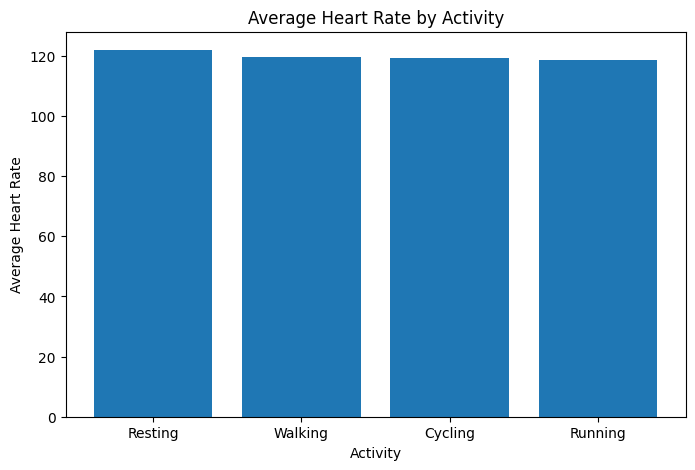

In [40]:
# ============================================================
# 5-5. 활동별 평균 심박수 시각화
# ============================================================
# 활동별 평균 심박수를 막대그래프로 확인한다.
# 이 그래프는 활동별 차이를 직관적으로 보기 위한 실습용 시각화이다.

import matplotlib.pyplot as plt

plot_df = activity_avg_sqlalchemy.sort_values("avg_heart_rate", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["activity"], plot_df["avg_heart_rate"])
plt.title("Average Heart Rate by Activity")
plt.xlabel("Activity")
plt.ylabel("Average Heart Rate")
plt.show()

## 5. 정제 데이터 기준 활동별 평균 생체지표 분석 결과

정제 데이터 4,240개를 기준으로 활동별 평균 생체지표를 분석했다.

이번 분석에서는 SQLAlchemy Core와 PyMongo를 각각 사용했다.  
SQLAlchemy Core에서는 select, func.avg, group_by를 사용했고, PyMongo에서는 Aggregation Pipeline의 $group과 $avg를 사용했다.

분석 결과, 평균 심박수는 Resting에서 121.95로 가장 높게 나타났다.  
평균 산소포화도는 Running에서 95.17로 가장 높았고, 평균 체온도 Running에서 37.52로 가장 높게 나타났다.

평균 호흡수는 Resting에서 18.21로 가장 높았으며, 평균 걸음 수는 Walking에서 102.33으로 가장 높게 나타났다.

다만 데이터 출처와 수집 방식이 명확하지 않기 때문에, Resting의 평균 심박수와 호흡수가 가장 높게 나온 결과를 실제 생리적 현상으로 단정하기는 어렵다.

따라서 이 결과는 활동 강도를 해석하기 위한 근거라기보다는, SQLAlchemy Core와 PyMongo를 이용해 같은 집계 분석을 수행하고 결과를 비교한 실습 결과로 해석하는 것이 적절하다.

SQLAlchemy Core와 PyMongo 결과는 모든 활동에서 동일하게 나왔다.  
이를 통해 MySQL 기반 집계 분석과 MongoDB 기반 집계 분석을 모두 구현하고, 두 결과를 비교할 수 있음을 확인했다.

# 6. SQLAlchemy Core 기반 위험 이벤트 탐지

이번 단계에서는 정제 데이터에서 위험 이벤트 후보를 탐지한다.

분석 기준은 다음과 같다.

- 고심박: heart_rate > 150
- 고체온: body_temp >= 38.0
- 저산소: blood_oxygen < 94

이번 분석은 SQL 문자열을 직접 작성하지 않고, SQLAlchemy Core 문법을 사용한다.

SQLAlchemy Core의 select, func, case, or_, where, group_by를 활용하여 활동별 위험 이벤트 개수와 비율을 계산한다.

이 기준은 실습용 분석 기준이며, 실제 의학적 진단 기준으로 해석하지 않는다.

In [41]:
# ============================================================
# 6-1. SQLAlchemy Core 테이블 준비
# ============================================================
# MySQL에 저장된 정제 테이블을 SQLAlchemy Core 객체로 불러온다.
# 이후부터는 SQL 문자열 대신 Python 문법으로 SQL 쿼리를 만든다.

from sqlalchemy import MetaData, Table, select, func, case, or_

metadata = MetaData()

biometric_clean = Table(
    "biometric_data_clean",
    metadata,
    autoload_with=engine
)

b = biometric_clean

print("테이블 불러오기 완료")
print("테이블 이름:", b.name)
print("컬럼 목록:", list(b.c.keys()))

테이블 불러오기 완료
테이블 이름: biometric_data_clean
컬럼 목록: ['timestamp', 'heart_rate', 'blood_oxygen', 'body_temp', 'resp_rate', 'step_count', 'activity', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'is_tampered']


In [42]:
# ============================================================
# 6-2. 활동별 위험 이벤트 개수와 비율 계산
# ============================================================
# 고심박, 고체온, 저산소 조건을 기준으로 activity별 위험 이벤트를 계산한다.

high_hr_condition = b.c.heart_rate > 150
high_temp_condition = b.c.body_temp >= 38.0
low_spo2_condition = b.c.blood_oxygen < 94

any_risk_condition = or_(
    high_hr_condition,
    high_temp_condition,
    low_spo2_condition
)

total_count = func.count()

high_hr_count = func.sum(
    case(
        (high_hr_condition, 1),
        else_=0
    )
)

high_temp_count = func.sum(
    case(
        (high_temp_condition, 1),
        else_=0
    )
)

low_spo2_count = func.sum(
    case(
        (low_spo2_condition, 1),
        else_=0
    )
)

any_risk_count = func.sum(
    case(
        (any_risk_condition, 1),
        else_=0
    )
)

stmt = (
    select(
        b.c.activity,
        total_count.label("total_count"),

        high_hr_count.label("high_hr_count"),
        func.round(high_hr_count / total_count * 100, 2).label("high_hr_ratio"),

        high_temp_count.label("high_temp_count"),
        func.round(high_temp_count / total_count * 100, 2).label("high_temp_ratio"),

        low_spo2_count.label("low_spo2_count"),
        func.round(low_spo2_count / total_count * 100, 2).label("low_spo2_ratio"),

        any_risk_count.label("any_risk_count"),
        func.round(any_risk_count / total_count * 100, 2).label("any_risk_ratio")
    )
    .group_by(b.c.activity)
    .order_by(any_risk_count.desc())
)

with engine.connect() as conn:
    risk_by_activity = pd.DataFrame(conn.execute(stmt).mappings().all())

display(risk_by_activity)

,activity,any_risk_count,any_risk_ratio,high_hr_count,high_hr_ratio,high_temp_count,high_temp_ratio,low_spo2_count,low_spo2_ratio,total_count
0,Walking,786,70.94,264,23.83,360,32.49,454,40.97,1108
1,Cycling,721,67.83,253,23.80,313,29.44,448,42.14,1063
2,Running,718,67.93,235,22.23,357,33.77,404,38.22,1057
3,Resting,715,70.65,265,26.19,333,32.91,405,40.02,1012


In [43]:
# ============================================================
# 6-3. 위험 이벤트 샘플 확인
# ============================================================
# 위험 이벤트 조건에 해당하는 실제 데이터 일부를 확인한다.
# 각 조건에 해당하는지 flag 컬럼으로 표시한다.

stmt_sample = (
    select(
        b.c.timestamp,
        b.c.activity,
        b.c.heart_rate,
        b.c.blood_oxygen,
        b.c.body_temp,
        b.c.resp_rate,
        b.c.step_count,

        case(
            (high_hr_condition, 1),
            else_=0
        ).label("high_hr_flag"),

        case(
            (high_temp_condition, 1),
            else_=0
        ).label("high_temp_flag"),

        case(
            (low_spo2_condition, 1),
            else_=0
        ).label("low_spo2_flag")
    )
    .where(any_risk_condition)
    .order_by(b.c.timestamp)
    .limit(15)
)

with engine.connect() as conn:
    risk_sample = pd.DataFrame(conn.execute(stmt_sample).mappings().all())

display(risk_sample)

,activity,blood_oxygen,body_temp,heart_rate,high_hr_flag,high_temp_flag,low_spo2_flag,resp_rate,step_count,timestamp
0,Cycling,90.9011363293,36.3120517554,163.0000000000,1,0,1,13.0000000000,100,2024-04-01 00:00:00
1,Cycling,95.9863717883,38.8567118562,177.0000000000,1,1,0,22.0000000000,95,2024-04-01 00:00:30
2,Walking,92.9254042848,37.3277124200,63.0000000000,0,0,1,19.0000000000,161,2024-04-01 00:00:40
3,Walking,96.8389335478,38.0724228729,89.0000000000,0,1,0,24.0000000000,34,2024-04-01 00:00:50
4,Walking,91.1285816494,36.5302806873,179.0000000000,1,0,1,13.0000000000,49,2024-04-01 00:01:10
5,Walking,91.0126518099,37.6203501281,136.0000000000,0,0,1,16.0000000000,1,2024-04-01 00:01:30
6,Running,98.0796568926,36.4919639159,161.0000000000,1,0,0,23.0000000000,101,2024-04-01 00:02:00
7,Walking,93.6808563767,37.3904331937,166.0000000000,1,0,1,19.0000000000,176,2024-04-01 00:02:10
8,Cycling,91.2507822682,37.8169598155,146.0000000000,0,0,1,21.0000000000,129,2024-04-01 00:02:20
9,Resting,90.4149930439,37.4683475961,127.0000000000,0,0,1,23.0000000000,71,2024-04-01 00:02:30


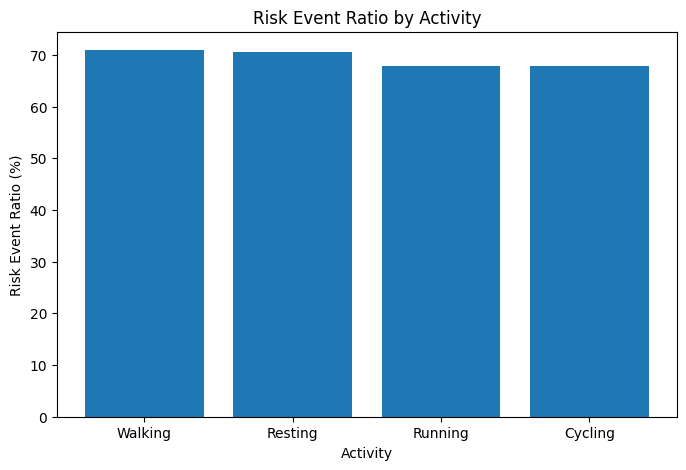

In [44]:
# ============================================================
# 6-4. 활동별 위험 이벤트 비율 시각화
# ============================================================
# activity별로 위험 이벤트가 발생한 비율을 막대그래프로 확인한다.

import matplotlib.pyplot as plt

plot_df = risk_by_activity.sort_values("any_risk_ratio", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["activity"], plot_df["any_risk_ratio"])
plt.title("Risk Event Ratio by Activity")
plt.xlabel("Activity")
plt.ylabel("Risk Event Ratio (%)")
plt.show()

In [45]:
# ============================================================
# 6-5. 위험 이벤트가 가장 많은 활동 확인
# ============================================================
# 해석 문장에 바로 사용할 수 있도록 위험 이벤트가 가장 많은 활동을 출력한다.

top_risk = risk_by_activity.sort_values("any_risk_ratio", ascending=False).iloc[0]

print("위험 이벤트 비율이 가장 높은 활동:", top_risk["activity"])
print("위험 이벤트 개수:", top_risk["any_risk_count"])
print("위험 이벤트 비율:", top_risk["any_risk_ratio"], "%")

위험 이벤트 비율이 가장 높은 활동: Walking
위험 이벤트 개수: 786
위험 이벤트 비율: 70.94 %


## 6. SQLAlchemy Core 기반 위험 이벤트 탐지 결과

정제 데이터 4,240개를 기준으로 고심박, 고체온, 저산소 위험 이벤트 후보를 탐지했다.

위험 이벤트 기준은 다음과 같이 설정했다.

- 고심박: heart_rate > 150
- 고체온: body_temp >= 38.0
- 저산소: blood_oxygen < 94

분석 결과, 위험 이벤트 비율이 가장 높은 활동은 Walking으로 나타났다.  
Walking은 전체 1,108개 데이터 중 786개가 하나 이상의 위험 조건에 해당했고, 위험 이벤트 비율은 70.94%였다.

Resting은 70.65%, Running은 67.93%, Cycling은 67.83%로 나타났다.

활동별 위험 이벤트 비율 차이는 크지 않았으며, 모든 활동에서 위험 이벤트 후보 비율이 비교적 높게 나타났다.

다만 이 결과를 실제 건강 위험으로 단정하기는 어렵다.  
데이터 출처와 수집 방식이 명확하지 않고, 본 프로젝트에서 사용한 위험 기준도 실습용으로 설정한 기준이기 때문이다.

따라서 이번 결과는 실제 의학적 진단이 아니라, SQLAlchemy Core를 활용해 조건 기반 위험 이벤트를 탐지하고 활동별로 집계하는 실습 결과로 해석하는 것이 적절하다.

이번 단계에서는 SQLAlchemy Core의 select, func.sum, case, or_, where, group_by, order_by를 사용하여 위험 이벤트 개수와 비율을 계산했다.

# 7. 시간대별 생체지표 및 위험 이벤트 패턴 분석

이번 단계에서는 정제 데이터를 기준으로 시간대별 생체지표 패턴을 분석한다.

timestamp에서 시간(hour)을 추출한 뒤, 시간대별 평균 심박수, 평균 체온, 평균 산소포화도, 위험 이벤트 개수와 비율을 계산한다.

이번 분석은 SQLAlchemy Core 문법을 사용한다.

이를 통해 하루 중 특정 시간대에 생체지표나 위험 이벤트 후보가 더 많이 나타나는지 확인한다.

In [46]:
# ============================================================
# 7-1. 시간대별 생체지표 및 위험 이벤트 패턴 분석
# ============================================================
# timestamp에서 시간(hour)을 추출한 뒤,
# 시간대별 평균 생체지표와 위험 이벤트 비율을 계산한다.

from sqlalchemy import MetaData, Table, select, func, case, or_

metadata = MetaData()

b = Table(
    "biometric_data_clean",
    metadata,
    autoload_with=engine
)

hour_col = func.hour(b.c.timestamp)

high_hr_condition = b.c.heart_rate > 150
high_temp_condition = b.c.body_temp >= 38.0
low_spo2_condition = b.c.blood_oxygen < 94

any_risk_condition = or_(
    high_hr_condition,
    high_temp_condition,
    low_spo2_condition
)

total_count = func.count()

def count_case(condition):
    return func.sum(
        case(
            (condition, 1),
            else_=0
        )
    )

any_risk_count = count_case(any_risk_condition)

stmt = (
    select(
        hour_col.label("hour"),
        total_count.label("total_count"),
        func.round(func.avg(b.c.heart_rate), 2).label("avg_heart_rate"),
        func.round(func.avg(b.c.blood_oxygen), 2).label("avg_blood_oxygen"),
        func.round(func.avg(b.c.body_temp), 2).label("avg_body_temp"),
        any_risk_count.label("any_risk_count"),
        func.round(any_risk_count / total_count * 100, 2).label("any_risk_ratio")
    )
    .group_by(hour_col)
    .order_by(hour_col)
)

with engine.connect() as conn:
    hourly_pattern = pd.DataFrame(conn.execute(stmt).mappings().all())

display(hourly_pattern)

,any_risk_count,any_risk_ratio,avg_blood_oxygen,avg_body_temp,avg_heart_rate,hour,total_count
0,216,69.23,95.18,37.53,122.14,0,312
1,210,69.54,94.75,37.47,119.03,1,302
2,224,70.66,95.21,37.56,117.26,2,317
3,199,66.33,95.09,37.50,120.08,3,300
4,229,71.79,94.71,37.52,122.19,4,319
5,189,63.42,95.08,37.41,120.09,5,298
6,221,72.22,94.88,37.55,119.07,6,306
7,214,70.86,95.09,37.53,121.93,7,302
8,205,67.21,95.00,37.35,120.70,8,305
9,205,69.02,94.96,37.47,118.02,9,297


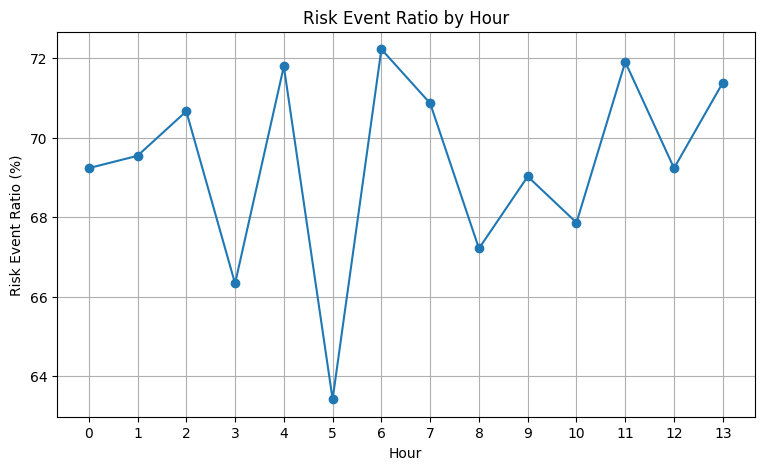

In [47]:
# ============================================================
# 7-2. 시간대별 위험 이벤트 비율 시각화
# ============================================================
# 시간 흐름에 따라 위험 이벤트 비율이 어떻게 변하는지 선 그래프로 확인한다.

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(hourly_pattern["hour"], hourly_pattern["any_risk_ratio"], marker="o")
plt.title("Risk Event Ratio by Hour")
plt.xlabel("Hour")
plt.ylabel("Risk Event Ratio (%)")
plt.xticks(hourly_pattern["hour"])
plt.grid(True)
plt.show()

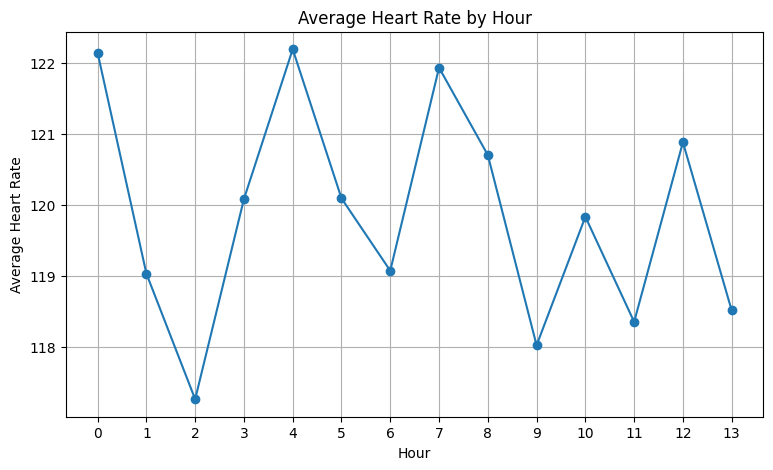

In [48]:
# ============================================================
# 7-3. 시간대별 평균 심박수 시각화
# ============================================================
# 시간대별 평균 심박수 변화를 확인한다.

plt.figure(figsize=(9, 5))
plt.plot(hourly_pattern["hour"], hourly_pattern["avg_heart_rate"], marker="o")
plt.title("Average Heart Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Heart Rate")
plt.xticks(hourly_pattern["hour"])
plt.grid(True)
plt.show()

In [49]:
# ============================================================
# 7-4. 위험 이벤트 비율이 가장 높은 시간대 확인
# ============================================================
# 해석 문장에 사용할 수 있도록 위험 이벤트 비율이 가장 높은 시간대를 확인한다.

top_hour = hourly_pattern.sort_values("any_risk_ratio", ascending=False).iloc[0]

print("위험 이벤트 비율이 가장 높은 시간대:", int(top_hour["hour"]), "시")
print("위험 이벤트 개수:", top_hour["any_risk_count"])
print("위험 이벤트 비율:", top_hour["any_risk_ratio"], "%")
print("평균 심박수:", top_hour["avg_heart_rate"])
print("평균 체온:", top_hour["avg_body_temp"])

위험 이벤트 비율이 가장 높은 시간대: 6 시
위험 이벤트 개수: 221
위험 이벤트 비율: 72.22 %
평균 심박수: 119.07
평균 체온: 37.55


## 7. 시간대별 생체지표 및 위험 이벤트 패턴 분석 결과

정제 데이터 기준으로 timestamp에서 hour를 추출한 뒤, 시간대별 평균 생체지표와 위험 이벤트 비율을 분석했다.

분석 결과, 위험 이벤트 비율이 가장 높은 시간대는 6시로 나타났다.  
6시에는 총 306개 데이터 중 221개가 하나 이상의 위험 조건에 해당했고, 위험 이벤트 비율은 72.22%였다.

그 다음으로는 11시 71.90%, 4시 71.79%, 13시 71.38% 순으로 위험 이벤트 비율이 높게 나타났다.

시간대별 평균 심박수는 0시와 4시에서 상대적으로 높게 나타났다.  
0시의 평균 심박수는 122.14, 4시의 평균 심박수는 122.19였다.

다만 전체 시간대에서 위험 이벤트 비율이 약 63%에서 72% 사이로 비교적 높게 나타났기 때문에, 특정 시간대만 뚜렷하게 위험하다고 단정하기는 어렵다.

또한 데이터의 시간 범위가 0시부터 13시까지로 제한되어 있어 하루 전체 패턴을 분석했다고 보기는 어렵다.

따라서 이번 결과는 실제 건강 패턴을 해석하기 위한 분석이라기보다는, SQLAlchemy Core를 활용해 timestamp에서 시간 정보를 추출하고 시간대별 집계 분석을 수행한 실습 결과로 해석하는 것이 적절하다.

이번 단계에서는 SQLAlchemy Core의 func.hour, select, func.avg, func.sum, case, or_, group_by, order_by를 사용하여 시간대별 생체지표와 위험 이벤트 비율을 계산했다.

# 8. 복합 위험군 탐지

이번 단계에서는 정제 데이터에서 복합 위험군 후보를 탐지한다.

앞에서는 고심박, 고체온, 저산소를 각각 따로 확인했다.

이번에는 아래 조건들이 동시에 발생한 데이터를 확인한다.

- 고심박 + 고체온
- 고심박 + 저산소
- 고체온 + 저산소
- 고심박 + 고체온 + 저산소
- 위험 조건 2개 이상 동시 발생

이번 분석은 SQLAlchemy Core 문법을 사용한다.

이 기준은 실습용 분석 기준이며, 실제 의학적 진단 기준으로 해석하지 않는다.

In [50]:
# ============================================================
# 8-1. 활동별 복합 위험군 탐지
# ============================================================
# 고심박, 고체온, 저산소 중 2개 이상이 동시에 발생한 데이터를 찾는다.

from sqlalchemy import MetaData, Table, select, func, case, and_

metadata = MetaData()

b = Table(
    "biometric_data_clean",
    metadata,
    autoload_with=engine
)

# 위험 조건 정의
high_hr_condition = b.c.heart_rate > 150
high_temp_condition = b.c.body_temp >= 38.0
low_spo2_condition = b.c.blood_oxygen < 94

# 조건을 1 또는 0으로 바꾸는 함수
def flag(condition):
    return case((condition, 1), else_=0)

def count_case(condition):
    return func.sum(case((condition, 1), else_=0))

total_count = func.count()

# 위험 점수: 조건 3개 중 몇 개에 해당하는지
risk_score = (
    flag(high_hr_condition) +
    flag(high_temp_condition) +
    flag(low_spo2_condition)
)

two_or_more_condition = risk_score >= 2

stmt = (
    select(
        b.c.activity,
        total_count.label("total_count"),

        count_case(and_(high_hr_condition, high_temp_condition)).label("high_hr_high_temp_count"),
        func.round(count_case(and_(high_hr_condition, high_temp_condition)) / total_count * 100, 2).label("high_hr_high_temp_ratio"),

        count_case(and_(high_hr_condition, low_spo2_condition)).label("high_hr_low_spo2_count"),
        func.round(count_case(and_(high_hr_condition, low_spo2_condition)) / total_count * 100, 2).label("high_hr_low_spo2_ratio"),

        count_case(and_(high_temp_condition, low_spo2_condition)).label("high_temp_low_spo2_count"),
        func.round(count_case(and_(high_temp_condition, low_spo2_condition)) / total_count * 100, 2).label("high_temp_low_spo2_ratio"),

        count_case(and_(high_hr_condition, high_temp_condition, low_spo2_condition)).label("all_three_count"),
        func.round(count_case(and_(high_hr_condition, high_temp_condition, low_spo2_condition)) / total_count * 100, 2).label("all_three_ratio"),

        count_case(two_or_more_condition).label("two_or_more_count"),
        func.round(count_case(two_or_more_condition) / total_count * 100, 2).label("two_or_more_ratio")
    )
    .group_by(b.c.activity)
    .order_by(count_case(two_or_more_condition).desc())
)

with engine.connect() as conn:
    complex_risk_by_activity = pd.DataFrame(conn.execute(stmt).mappings().all())

display(complex_risk_by_activity)

,activity,all_three_count,all_three_ratio,high_hr_high_temp_count,high_hr_high_temp_ratio,high_hr_low_spo2_count,high_hr_low_spo2_ratio,high_temp_low_spo2_count,high_temp_low_spo2_ratio,total_count,two_or_more_count,two_or_more_ratio
0,Cycling,30,2.82,74,6.96,109,10.25,140,13.17,1063,263,24.74
1,Walking,40,3.61,88,7.94,101,9.12,143,12.91,1108,252,22.74
2,Running,26,2.46,90,8.51,79,7.47,135,12.77,1057,252,23.84
3,Resting,37,3.66,89,8.79,108,10.67,128,12.65,1012,251,24.80


In [51]:
# ============================================================
# 8-2. 복합 위험군 샘플 확인
# ============================================================
# 위험 조건이 2개 이상 동시에 발생한 실제 데이터 일부를 확인한다.

stmt_sample = (
    select(
        b.c.timestamp,
        b.c.activity,
        b.c.heart_rate,
        b.c.blood_oxygen,
        b.c.body_temp,
        b.c.resp_rate,
        b.c.step_count,

        flag(high_hr_condition).label("high_hr_flag"),
        flag(high_temp_condition).label("high_temp_flag"),
        flag(low_spo2_condition).label("low_spo2_flag"),
        risk_score.label("risk_score")
    )
    .where(two_or_more_condition)
    .order_by(risk_score.desc(), b.c.timestamp)
    .limit(15)
)

with engine.connect() as conn:
    complex_risk_sample = pd.DataFrame(conn.execute(stmt_sample).mappings().all())

display(complex_risk_sample)

,activity,blood_oxygen,body_temp,heart_rate,high_hr_flag,high_temp_flag,low_spo2_flag,resp_rate,risk_score,step_count,timestamp
0,Cycling,92.4999873522,38.2680497474,171.0000000000,1,1,1,18.0000000000,3,159,2024-04-01 00:19:10
1,Walking,92.5227895958,38.2768032187,172.0000000000,1,1,1,14.0000000000,3,177,2024-04-01 00:19:50
2,Cycling,92.1046174768,38.4971560971,178.0000000000,1,1,1,17.0000000000,3,125,2024-04-01 00:23:40
3,Cycling,90.3029322648,38.7551049443,167.0000000000,1,1,1,14.0000000000,3,5,2024-04-01 00:26:10
4,Resting,93.1083010103,38.7894032589,175.0000000000,1,1,1,13.0000000000,3,24,2024-04-01 00:28:50
5,Resting,92.5608842624,38.1143609605,177.0000000000,1,1,1,22.0000000000,3,60,2024-04-01 00:35:40
6,Running,92.6257237144,38.4955976102,159.0000000000,1,1,1,12.0000000000,3,140,2024-04-01 00:40:40
7,Resting,90.7661076426,38.0962643666,163.0000000000,1,1,1,24.0000000000,3,87,2024-04-01 00:43:10
8,Walking,92.6870073575,38.0354058495,175.0000000000,1,1,1,15.0000000000,3,111,2024-04-01 00:49:10
9,Resting,91.2903678781,38.9505615631,151.0000000000,1,1,1,21.0000000000,3,173,2024-04-01 01:03:50


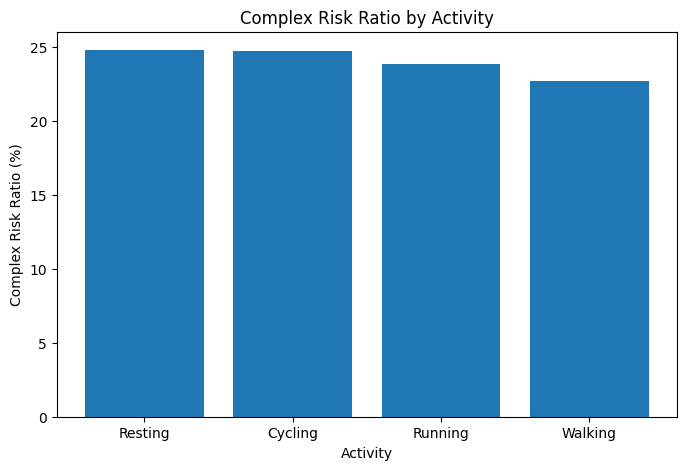

In [52]:
# ============================================================
# 8-3. 활동별 복합 위험군 비율 시각화
# ============================================================
# 위험 조건이 2개 이상 동시에 발생한 비율을 활동별로 확인한다.

import matplotlib.pyplot as plt

plot_df = complex_risk_by_activity.sort_values("two_or_more_ratio", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["activity"], plot_df["two_or_more_ratio"])
plt.title("Complex Risk Ratio by Activity")
plt.xlabel("Activity")
plt.ylabel("Complex Risk Ratio (%)")
plt.show()

In [53]:
# ============================================================
# 8-4. 복합 위험군 비율이 가장 높은 활동 확인
# ============================================================

top_complex_risk = complex_risk_by_activity.sort_values("two_or_more_ratio", ascending=False).iloc[0]

print("복합 위험군 비율이 가장 높은 활동:", top_complex_risk["activity"])
print("복합 위험군 개수:", top_complex_risk["two_or_more_count"])
print("복합 위험군 비율:", top_complex_risk["two_or_more_ratio"], "%")

복합 위험군 비율이 가장 높은 활동: Resting
복합 위험군 개수: 251
복합 위험군 비율: 24.80 %


## 8. 복합 위험군 탐지 결과

정제 데이터 기준으로 고심박, 고체온, 저산소 조건 중 2개 이상이 동시에 발생한 복합 위험군 후보를 탐지했다.

분석 기준은 다음과 같다.

- 고심박: heart_rate > 150
- 고체온: body_temp >= 38.0
- 저산소: blood_oxygen < 94

분석 결과, 복합 위험군 비율이 가장 높은 활동은 Resting으로 나타났다.  
Resting은 전체 1,012개 데이터 중 251개가 위험 조건 2개 이상에 해당했고, 복합 위험군 비율은 24.80%였다.

그 다음으로는 Cycling 24.74%, Running 23.84%, Walking 22.74% 순으로 나타났다.

위험 조건 3개가 모두 동시에 발생한 데이터도 확인되었다.  
Resting에서는 37개, Walking에서는 40개, Cycling에서는 30개, Running에서는 26개가 세 가지 위험 조건에 모두 해당했다.

다만 활동별 복합 위험군 비율의 차이는 크지 않았다.  
따라서 특정 활동이 확실히 더 위험하다고 단정하기보다는, 모든 활동에서 일정 수준의 복합 위험 후보가 존재한다고 해석하는 것이 적절하다.

이번 분석은 실제 의학적 진단이 아니라, SQLAlchemy Core를 활용해 복합 조건을 만들고 조건 기반 데이터를 탐지하는 실습 결과로 해석한다.

이번 단계에서는 SQLAlchemy Core의 case, and_, func.sum, group_by, where를 사용하여 위험 조건 2개 이상이 동시에 발생한 데이터를 탐지했다.

## 8. 복합 위험군 탐지 결과

정제 데이터 기준으로 고심박, 고체온, 저산소 조건 중 2개 이상이 동시에 발생한 복합 위험군 후보를 탐지했다.

분석 기준은 다음과 같다.

- 고심박: heart_rate > 150
- 고체온: body_temp >= 38.0
- 저산소: blood_oxygen < 94

분석 결과, 복합 위험군 비율이 가장 높은 활동은 Resting으로 나타났다.  
Resting은 전체 1,012개 데이터 중 251개가 위험 조건 2개 이상에 해당했고, 복합 위험군 비율은 24.80%였다.

그 다음으로는 Cycling 24.74%, Running 23.84%, Walking 22.74% 순으로 나타났다.

위험 조건 3개가 모두 동시에 발생한 데이터도 확인되었다.  
Resting에서는 37개, Walking에서는 40개, Cycling에서는 30개, Running에서는 26개가 세 가지 위험 조건에 모두 해당했다.

다만 활동별 복합 위험군 비율의 차이는 크지 않았다.  
따라서 특정 활동이 확실히 더 위험하다고 단정하기보다는, 모든 활동에서 일정 수준의 복합 위험 후보가 존재한다고 해석하는 것이 적절하다.

이번 분석은 실제 의학적 진단이 아니라, SQLAlchemy Core를 활용해 복합 조건을 만들고 조건 기반 데이터를 탐지하는 실습 결과로 해석한다.

이번 단계에서는 SQLAlchemy Core의 case, and_, func.sum, group_by, where를 사용하여 위험 조건 2개 이상이 동시에 발생한 데이터를 탐지했다.

# 9. 원본 데이터와 정제 데이터 비교

이번 단계에서는 원본 데이터 df와 정제 데이터 clean_df를 비교한다.

정제 전후로 데이터 개수, 주요 평균값, 위험 이벤트 비율이 어떻게 달라졌는지 간단히 확인한다.

그래프는 정제 전후 위험 이벤트 비율만 시각화한다.

,item,original_df,clean_df,difference
0,row_count,5000.00,4240.00,-760.00
1,heart_rate_mean,119.49,119.88,0.39
2,blood_oxygen_mean,95.01,94.99,-0.02
3,body_temp_mean,37.53,37.48,-0.05
4,resp_rate_mean,18.07,18.06,-0.01
5,step_count_mean,99.34,99.68,0.34
6,risk_event_ratio,70.82,69.34,-1.48


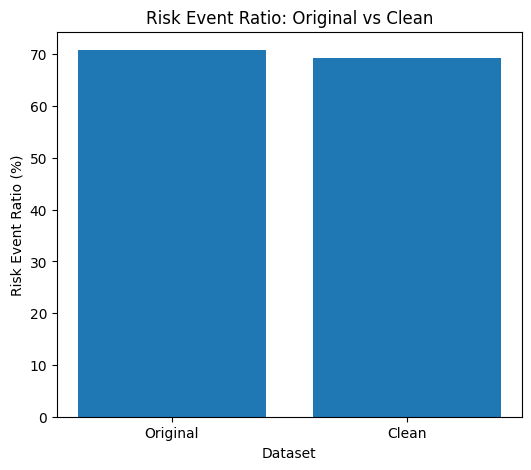

In [60]:
# ============================================================
# 9. 원본 df와 정제 clean_df 비교
# ============================================================
# 정제 전후 데이터 개수, 평균값, 위험 이벤트 비율을 비교한다.
# 그래프는 위험 이벤트 비율 변화만 시각화한다.

import matplotlib.pyplot as plt

def risk_ratio(data):
    risk_count = (
        (data["heart_rate"] > 150) |
        (data["body_temp"] >= 38.0) |
        (data["blood_oxygen"] < 94)
    ).sum()

    return round(risk_count / len(data) * 100, 2)

compare_summary = pd.DataFrame({
    "item": [
        "row_count",
        "heart_rate_mean",
        "blood_oxygen_mean",
        "body_temp_mean",
        "resp_rate_mean",
        "step_count_mean",
        "risk_event_ratio"
    ],
    "original_df": [
        len(df),
        round(df["heart_rate"].mean(), 2),
        round(df["blood_oxygen"].mean(), 2),
        round(df["body_temp"].mean(), 2),
        round(df["resp_rate"].mean(), 2),
        round(df["step_count"].mean(), 2),
        risk_ratio(df)
    ],
    "clean_df": [
        len(clean_df),
        round(clean_df["heart_rate"].mean(), 2),
        round(clean_df["blood_oxygen"].mean(), 2),
        round(clean_df["body_temp"].mean(), 2),
        round(clean_df["resp_rate"].mean(), 2),
        round(clean_df["step_count"].mean(), 2),
        risk_ratio(clean_df)
    ]
})

compare_summary["difference"] = compare_summary["clean_df"] - compare_summary["original_df"]

display(compare_summary)


# 위험 이벤트 비율만 그래프로 비교
risk_plot = compare_summary[compare_summary["item"] == "risk_event_ratio"]

plt.figure(figsize=(6, 5))
plt.bar(["Original", "Clean"], [
    risk_plot["original_df"].values[0],
    risk_plot["clean_df"].values[0]
])

plt.title("Risk Event Ratio: Original vs Clean")
plt.xlabel("Dataset")
plt.ylabel("Risk Event Ratio (%)")
plt.show()

## 9. 원본 데이터와 정제 데이터 비교 결과

원본 데이터와 정제 데이터를 비교한 결과, 데이터 개수는 5,000개에서 4,240개로 줄어들었다.  
정제 과정에서 제거된 데이터는 760개였다.

주요 생체지표 평균값은 정제 전후로 큰 차이를 보이지 않았다.

평균 심박수는 119.49에서 119.88로 약간 증가했고, 평균 산소포화도는 95.01에서 94.99로 거의 변화가 없었다.  
평균 체온은 37.53에서 37.48로 소폭 감소했고, 평균 호흡수와 평균 걸음 수도 큰 차이를 보이지 않았다.

위험 이벤트 비율은 원본 데이터에서 70.82%, 정제 데이터에서 69.34%로 나타났다.  
정제 후 위험 이벤트 비율은 1.48%p 감소했다.

이를 통해 센서 오류와 비현실적인 값을 제거했지만, 전체적인 생체지표 평균과 위험 이벤트 비율은 크게 달라지지 않았음을 확인했다.

따라서 이후 분석 결과는 정제 데이터 기준으로 진행해도 전체적인 데이터 패턴을 크게 왜곡하지 않는다고 볼 수 있다.

# 10. SQLAlchemy와 PyMongo 활용 비교 정리

이번 단계에서는 프로젝트에서 사용한 SQLAlchemy와 PyMongo의 역할을 정리한다.

같은 웨어러블 데이터를 MySQL과 MongoDB에 각각 저장했고, 일부 분석에서는 두 방식으로 같은 집계 분석을 수행했다.

SQLAlchemy는 MySQL 기반 정형 데이터 조회와 조건 기반 분석에 사용했고, PyMongo는 MongoDB document 저장과 Aggregation Pipeline 기반 집계 분석에 사용했다.

이를 통해 관계형 데이터베이스와 NoSQL 데이터베이스를 모두 활용하는 실습을 수행했다.

In [61]:
# ============================================================
# 10. SQLAlchemy와 PyMongo 활용 비교 정리
# ============================================================
# 프로젝트에서 SQLAlchemy와 PyMongo를 어디에 사용했는지 정리한다.

tool_summary = pd.DataFrame({
    "tool": [
        "SQLAlchemy",
        "PyMongo",
        "Pandas"
    ],
    "database": [
        "MySQL",
        "MongoDB",
        "Local DataFrame"
    ],
    "main_usage": [
        "정제 데이터 저장, SQLAlchemy Core 기반 집계/조건 분석",
        "Document 형태 데이터 저장, Aggregation Pipeline 기반 집계 분석",
        "데이터 품질 점검, clean_df 생성, 원본/정제 데이터 비교"
    ],
    "used_in_project": [
        "5번 활동별 평균 분석, 6번 위험 이벤트 탐지, 7번 시간대 분석, 8번 복합 위험군 탐지",
        "3번 MongoDB 저장, 5번 활동별 평균 분석 비교",
        "1번 데이터 확인, 4번 데이터 정제, 9번 정제 전후 비교"
    ]
})

display(tool_summary)

,tool,database,main_usage,used_in_project
0,SQLAlchemy,MySQL,"정제 데이터 저장, SQLAlchemy Core 기반 집계/조건 분석","5번 활동별 평균 분석, 6번 위험 이벤트 탐지, 7번 시간대 분석, 8번 복합 위..."
1,PyMongo,MongoDB,"Document 형태 데이터 저장, Aggregation Pipeline 기반 집계 분석","3번 MongoDB 저장, 5번 활동별 평균 분석 비교"
2,Pandas,Local DataFrame,"데이터 품질 점검, clean_df 생성, 원본/정제 데이터 비교","1번 데이터 확인, 4번 데이터 정제, 9번 정제 전후 비교"


## 10. SQLAlchemy와 PyMongo 활용 비교 결과

이번 프로젝트에서는 같은 웨어러블 생체신호 데이터를 MySQL과 MongoDB에 각각 저장하고 분석했다.

SQLAlchemy는 MySQL 데이터베이스와 연결하여 정제 데이터를 저장하고, SQLAlchemy Core 문법을 활용해 조건 기반 분석과 집계 분석을 수행하는 데 사용했다.

특히 select, func.avg, func.sum, case, group_by, where, order_by 등을 사용하여 활동별 평균 분석, 위험 이벤트 탐지, 시간대별 패턴 분석, 복합 위험군 탐지를 수행했다.

PyMongo는 MongoDB에 데이터를 document 형태로 저장하고, Aggregation Pipeline을 이용해 활동별 평균 생체지표 분석을 수행하는 데 사용했다.

5번 활동별 평균 분석에서는 SQLAlchemy Core와 PyMongo로 같은 분석을 수행했고, 두 결과가 동일하게 나오는 것을 확인했다.

Pandas는 데이터 불러오기, 데이터 품질 점검, clean_df 생성, 원본 데이터와 정제 데이터 비교에 사용했다.

즉, 이 프로젝트에서는 SQLAlchemy, PyMongo, Pandas를 각각 목적에 맞게 나누어 사용했다.

- SQLAlchemy: MySQL 기반 정형 데이터 분석
- PyMongo: MongoDB 기반 document 저장 및 집계 분석
- Pandas: 데이터 점검, 정제, 비교 분석

이를 통해 관계형 데이터베이스와 NoSQL 데이터베이스를 모두 활용한 데이터 저장, 조회, 집계, 비교 분석 과정을 실습했다.

# 프로젝트 결론

이번 프로젝트에서는 웨어러블 생체신호 데이터를 이용해 데이터 저장, 정제, 집계 분석, 위험 이벤트 탐지를 수행했다.

먼저 원본 데이터를 MySQL과 MongoDB에 각각 저장했고, 센서 오류와 비현실적인 값을 제거하여 정제 데이터인 clean_df를 생성했다.

이후 정제 데이터를 기준으로 활동별 평균 생체지표 분석, 위험 이벤트 탐지, 시간대별 패턴 분석, 복합 위험군 탐지를 수행했다.

SQLAlchemy Core를 사용하여 MySQL 기반 조건 조회와 집계 분석을 구현했고, PyMongo Aggregation Pipeline을 사용하여 MongoDB 기반 집계 분석도 수행했다.

분석 결과는 실제 의학적 진단이 아니라, 웨어러블 센서 데이터를 활용한 데이터베이스 실습 및 위험 이벤트 탐지 예제로 해석했다.

이 프로젝트를 통해 SQLAlchemy, PyMongo, Pandas를 함께 활용하여 데이터를 저장하고, 정제하고, 분석하는 전체 흐름을 경험했다.